# HIT Methodology Consolidation: Four Design Decisions

This notebook documents the four core methodology decisions for the Heat Insights Tool (HIT) in a single reproducible run.
Each section makes one decision, shows the evidence, and states the conclusion plainly.

**Cities:** Rio de Janeiro · Salvador · Teresina · Cáceres · Bengaluru  
**Dataset:** GSHTD (Zhang et al. 2022), 1 km daily Tmin and Tmax  
**Base period:** 2003-01-01 – 2020-12-31 (18 years)  
**Test year:** 2019  

---

| Decision | Question | Answer |
|---|---|---|
| 1 | Tmin or Tmax? | Tmin — smaller and more stable bias; avoids daytime-driven spatial artefacts in hot interiors |
| 2 | Citywide-A, per-pixel, or per-neighbourhood? | Citywide-A — equivalent neighbourhood rankings; simpler and less sensitive to edge-pixel noise |
| 3 | P90 or P95? | P90 primary, P95 confirmatory — rankings robust at both levels |
| 4 | Annual or moving-window percentile? | Annual preferred for most cities; direction reverses for Rio — needs wider-city validation before global use |

In [22]:
import sys, os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

# Reuse xclim-based moving-window ETCCDI implementation from the pipeline
sys.path.insert(0, os.path.abspath('../heat_threshold_analysis'))
from utils.heat import compute_tx90p_threshold, aggregate_to_neighbourhoods

In [23]:
# ---------------------------------------------------------------------------
# City registry
# Rio de Janeiro and Bengaluru are not in utils/heat.py CITIES (pipeline covers
# only salvador / teresina / caceres); they are registered here with their own
# data paths and neighbourhood files.
# ---------------------------------------------------------------------------

PIPELINE_DATA = '../heat_threshold_analysis/data'
RAW_DATA      = '../data'
NBD_DIR       = '../data/neighbourhoodShapes'
TEST_YEAR     = 2019

CITIES = {
    'rio_de_janeiro': {
        'label':     'Rio de Janeiro',
        'tmin_path': f'{RAW_DATA}/rio_de_janeiro_tmin.nc',
        'tmax_path': None,
        'nbhd_file': 'rio_de_janeiro_rj_bra_neighborhoods.geojson',
    },
    'salvador': {
        'label':     'Salvador',
        'tmin_path': f'{PIPELINE_DATA}/salvador_tmin.nc',
        'tmax_path': f'{PIPELINE_DATA}/salvador_tmax.nc',
        'tn90p_path': f'{PIPELINE_DATA}/salvador_tn90p_thresh.nc',
        'tx90p_path': f'{PIPELINE_DATA}/salvador_tx90p_thresh.nc',
        'nbhd_file': 'salvador_ba_bra_neighborhoods.geojson',
        'era5land_path': f'{RAW_DATA}/era5land_tx_daily_salvador_brazil.nc',
    },
    'teresina': {
        'label':     'Teresina',
        'tmin_path': f'{PIPELINE_DATA}/teresina_tmin.nc',
        'tmax_path': f'{PIPELINE_DATA}/teresina_tmax.nc',
        'tn90p_path': f'{PIPELINE_DATA}/teresina_tn90p_thresh.nc',
        'tx90p_path': f'{PIPELINE_DATA}/teresina_tx90p_thresh.nc',
        'nbhd_file': 'bairros-teresina-pi.geojson',
    },
    'caceres': {
        'label':     'Cáceres',
        'tmin_path': f'{PIPELINE_DATA}/caceres_tmin.nc',
        'tmax_path': f'{PIPELINE_DATA}/caceres_tmax.nc',
        'tn90p_path': f'{PIPELINE_DATA}/caceres_tn90p_thresh.nc',
        'tx90p_path': f'{PIPELINE_DATA}/caceres_tx90p_thresh.nc',
        'nbhd_file': 'bairros-caceres-mt.geojson',
    },
    'bengaluru': {
        'label':     'Bengaluru',
        'tmin_path': f'{RAW_DATA}/bengaluru_tmin.nc',
        'tmax_path': None,
        'nbhd_file': 'bengaluru_ka_ind_neighborhoods.geojson',
    },
}

CITY_ORDER = ['rio_de_janeiro', 'salvador', 'teresina', 'caceres', 'bengaluru']

In [24]:
# ---------------------------------------------------------------------------
# Data loading helpers
# ---------------------------------------------------------------------------

def _normalise_name_col(gdf):
    """Standardise neighbourhood label column to 'name'."""
    if 'name' in gdf.columns and gdf['name'].notna().any():
        return gdf
    for col in ['neighborhood_name', 'name_neighborhood', 'nome', 'bairro', 'NM_BAIRRO', 'NOME']:
        if col in gdf.columns and gdf[col].notna().any():
            gdf = gdf.copy()
            gdf['name'] = gdf[col].fillna(pd.Series(gdf.index.astype(str), index=gdf.index))
            return gdf
    gdf = gdf.copy()
    gdf['name'] = [f'Zone-{i+1:02d}' for i in range(len(gdf))]
    return gdf


def load_nc(path, expected_var=None):
    """Load a NetCDF file as a DataArray, ensuring 'units' attr is set."""
    if path is None or not os.path.exists(path):
        return None
    ds = xr.open_dataset(path)
    var = expected_var if expected_var and expected_var in ds else list(ds.data_vars)[0]
    da = ds[var].load()
    da.attrs.setdefault('units', 'degC')
    return da


def load_nbhd(city_key):
    cfg  = CITIES[city_key]
    path = os.path.join(NBD_DIR, cfg['nbhd_file'])
    if not os.path.exists(path):
        print(f"  {cfg['label']}: neighbourhood file not found — {path}")
        return None
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs('EPSG:4326')
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs('EPSG:4326')
    gdf = _normalise_name_col(gdf)
    return gdf[['name', 'geometry']].copy()


# Load Tmin for all 5 cities
print('Loading Tmin ...')
tmin = {}
for k in CITY_ORDER:
    da = load_nc(CITIES[k]['tmin_path'], 'tmin')
    if da is not None:
        print(f"  {CITIES[k]['label']}: {dict(zip(da.dims, da.shape))}  "
              f"{str(da.time.values[0])[:10]} – {str(da.time.values[-1])[:10]}")
    else:
        print(f"  {CITIES[k]['label']}: NOT FOUND")
    tmin[k] = da

# Load Tmax only where it exists (salvador / teresina / caceres)
print('\nLoading Tmax ...')
tmax = {}
for k in CITY_ORDER:
    path = CITIES[k].get('tmax_path')
    da   = load_nc(path, 'tmax') if path else None
    if da is not None:
        print(f"  {CITIES[k]['label']}: {dict(zip(da.dims, da.shape))}")
    tmax[k] = da

# Load neighbourhood boundaries for all 5 cities
print('\nLoading neighbourhood boundaries ...')
nbhd = {}
for k in CITY_ORDER:
    gdf = load_nbhd(k)
    if gdf is not None:
        print(f"  {CITIES[k]['label']}: {len(gdf)} neighbourhoods")
    nbhd[k] = gdf

Loading Tmin ...
  Rio de Janeiro: {'time': 6496, 'lat': 42, 'lon': 76}  2003-01-01 – 2020-12-30
  Salvador: {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 – 2020-12-30
  Teresina: {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 – 2020-12-30
  Cáceres: {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 – 2020-12-30
  Bengaluru: {'time': 6495, 'lat': 44, 'lon': 45}  2003-01-01 – 2020-12-30

Loading Tmax ...
  Salvador: {'time': 6497, 'lat': 55, 'lon': 67}
  Teresina: {'time': 6497, 'lat': 67, 'lon': 78}
  Cáceres: {'time': 6497, 'lat': 89, 'lon': 89}

Loading neighbourhood boundaries ...
  Rio de Janeiro: 162 neighbourhoods
  Salvador: 170 neighbourhoods
  Teresina: 123 neighbourhoods
  Cáceres: 47 neighbourhoods
  Bengaluru: 369 neighbourhoods


---

## Decision 1 — Which temperature variable: Tmax or Tmin?

**Question:** Does the choice of temperature variable affect bias magnitude and neighbourhood prioritisation?

**Why it matters:** Tmax captures peak daytime exposure, driven by surface properties (albedo, impervious cover, shade). Tmin captures the overnight recovery window, driven by atmospheric moisture and longwave re-emission — a physiologically distinct process. In cities where daytime temperatures are chronically extreme, the two variables can identify completely different neighbourhoods as high-priority. Choosing the wrong variable would systematically misprioritise heat adaptation investment.

**Test:** Compute TX90p and TN90p heat-day counts for each neighbourhood in 2019 (Salvador, Teresina, Cáceres, where both variables are available). Rank neighbourhoods by each metric. Spearman ρ between the two rankings measures how much the variable choice changes which neighbourhoods are prioritised.

**Additional evidence:**
- Alerta Rio rank validation: GSHTD TN90p neighbourhood rankings vs station-observed Tmin (Rio de Janeiro) — requires external data file
- Salvador bias check: GSHTD Tmax vs ERA5-Land Tmax as external gridded reference


In [25]:
# ---------------------------------------------------------------------------
# 1A  TX90p vs TN90p neighbourhood rank correlation
# Three cities have both Tmax and Tmin: salvador, teresina, caceres.
# Load pre-computed moving-window thresholds (5-day window, per=90 and per=95)
# produced by notebook 02_compute_baselines.
# ---------------------------------------------------------------------------

DUAL_CITIES = ['salvador', 'teresina', 'caceres']  # both Tmin and Tmax available

def load_thresh(city_key, var):
    """Load pipeline moving-window threshold (percentile, dayofyear, lat, lon)."""
    key  = f'{var}_path'
    path = CITIES[city_key].get(key)
    if not path or not os.path.exists(path):
        return None
    ds   = xr.open_dataset(path)
    dvar = 'tmin' if var == 'tn90p' else 'tmax'
    da   = ds[dvar].load()
    return da


def count_mw_exceedances(da, thresh_mw, year, percentile_idx=None):
    """
    Count days in `year` where da exceeds the moving-window threshold.
    Excludes Feb 29 so dayofyear maps cleanly to the 1–365 threshold coordinate.
    
    thresh_mw dims: (percentile, dayofyear, lat, lon) if percentile_idx given,
                    else (dayofyear, lat, lon).
    """
    thresh = thresh_mw
    if percentile_idx is not None and 'percentile' in thresh_mw.dims:
        thresh = thresh_mw.isel(percentile=percentile_idx)

    da_yr = da.sel(time=da.time.dt.year == year)
    da_yr = da_yr.sel(
        time=~((da_yr.time.dt.month == 2) & (da_yr.time.dt.day == 29))
    )
    doy           = da_yr.time.dt.dayofyear
    thresh_aligned = thresh.sel(dayofyear=doy)
    return (da_yr > thresh_aligned).sum(dim='time')


tn90p_thresh = {c: load_thresh(c, 'tn90p') for c in DUAL_CITIES}
tx90p_thresh = {c: load_thresh(c, 'tx90p') for c in DUAL_CITIES}

print('Loaded threshold shapes:')
for c in DUAL_CITIES:
    if tn90p_thresh[c] is not None:
        print(f'  {CITIES[c]["label"]}  TN90p: {dict(zip(tn90p_thresh[c].dims, tn90p_thresh[c].shape))}'
              f'  TX90p: {dict(zip(tx90p_thresh[c].dims, tx90p_thresh[c].shape))}')

Loaded threshold shapes:
  Salvador  TN90p: {'percentile': 2, 'lat': 48, 'lon': 67, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}
  Teresina  TN90p: {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}
  Cáceres  TN90p: {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}


In [26]:
# ---------------------------------------------------------------------------
# 1A  TX90p vs TN90p neighbourhood rank correlation
#
# For each city, we count heat days in TEST_YEAR under the moving-window TX90p
# threshold (applied to Tmax) and the TN90p threshold (applied to Tmin),
# aggregate to neighbourhoods, rank, and compute Spearman ρ.
#
# A high ρ means both variables point to the same neighbourhoods — the choice
# of variable does not matter much for prioritisation.
# A low or negative ρ means the two variables identify DIFFERENT neighbourhoods
# as high-priority — the variable choice is consequential.
#
# Note on prior values: the GSHTD analysis document (GSHTD_threshold_variants_analysis.md)
# records values of Salvador +0.82, Teresina +0.06, Cáceres −0.45 from notebook 09.
# These are recomputed live below. Differences from notebook 09 are expected because
# (a) notebook 09 may use a different test year or aggregation method, and
# (b) Salvador Tmax and Tmin grids have different bounding boxes (55 vs 48 lat rows),
# so some neighbourhoods have Tmax data but no Tmin coverage or vice versa.
# The live values below are authoritative for the current dataset.
# ---------------------------------------------------------------------------

DUAL_CITIES = ['salvador', 'teresina', 'caceres']  # both Tmin and Tmax available

def load_thresh(city_key, var):
    """Load pipeline moving-window threshold (percentile, dayofyear, lat, lon)."""
    key  = f'{var}_path'
    path = CITIES[city_key].get(key)
    if not path or not os.path.exists(path):
        return None
    ds   = xr.open_dataset(path)
    dvar = 'tmin' if var == 'tn90p' else 'tmax'
    da   = ds[dvar].load()
    return da


def count_mw_exceedances(da, thresh_mw, year, percentile_idx=None):
    """
    Count days in `year` where da exceeds the moving-window threshold.
    Excludes Feb 29 so dayofyear maps cleanly to the 1-365 threshold coordinate.
    percentile_idx: integer index into the 'percentile' dimension (0 = P90, 1 = P95).
    """
    thresh = thresh_mw
    if percentile_idx is not None and 'percentile' in thresh_mw.dims:
        thresh = thresh_mw.isel(percentile=percentile_idx)

    da_yr = da.sel(time=da.time.dt.year == year)
    da_yr = da_yr.sel(
        time=~((da_yr.time.dt.month == 2) & (da_yr.time.dt.day == 29))
    )
    doy            = da_yr.time.dt.dayofyear
    thresh_aligned = thresh.sel(dayofyear=doy)
    return (da_yr > thresh_aligned).sum(dim='time')


tn90p_thresh = {c: load_thresh(c, 'tn90p') for c in DUAL_CITIES}
tx90p_thresh = {c: load_thresh(c, 'tx90p') for c in DUAL_CITIES}

print('Loaded threshold shapes:')
for c in DUAL_CITIES:
    if tn90p_thresh[c] is not None:
        print(f'  {CITIES[c]["label"]}  '
              f'TN90p: {dict(zip(tn90p_thresh[c].dims, tn90p_thresh[c].shape))}  '
              f'TX90p: {dict(zip(tx90p_thresh[c].dims, tx90p_thresh[c].shape))}')

# Percentile index 0 = P90, 1 = P95 (order from notebook 02)
p90_idx = 0

rho_records = []

for c in DUAL_CITIES:
    if tn90p_thresh[c] is None or tmin[c] is None or tmax[c] is None:
        print(f'  {CITIES[c]["label"]}: skipping (missing data)')
        continue

    gdf = nbhd[c]
    if gdf is None:
        print(f'  {CITIES[c]["label"]}: skipping (no neighbourhood boundaries)')
        continue

    tn_days = count_mw_exceedances(tmin[c], tn90p_thresh[c], TEST_YEAR, p90_idx)
    tx_days = count_mw_exceedances(tmax[c], tx90p_thresh[c], TEST_YEAR, p90_idx)

    tn_nbhd = aggregate_to_neighbourhoods(tn_days, gdf, col='tn90p_days')
    tx_nbhd = aggregate_to_neighbourhoods(tx_days, gdf, col='tx90p_days')

    merged = (
        tn_nbhd[['name', 'tn90p_days']]
        .merge(tx_nbhd[['name', 'tx90p_days']], on='name')
        .dropna()
    )

    rho, pval = spearmanr(merged['tn90p_days'], merged['tx90p_days'])
    n = len(merged)
    p_str = '<0.001' if pval < 0.001 else f'{pval:.3f}'
    print(f'  {CITIES[c]["label"]:12s}  n={n:3d}  '
          f'Spearman ρ(TX90p vs TN90p) = {rho:+.3f}  p={p_str}')
    rho_records.append({'City': CITIES[c]['label'], 'n': n,
                        'ρ (TX90p vs TN90p)': rho, 'p-value': pval})

rho_d1_df = pd.DataFrame(rho_records)
print()
print('Interpretation:')
for _, row in rho_d1_df.iterrows():
    rho = row['ρ (TX90p vs TN90p)']
    if rho > 0.7:
        interp = 'strong agreement — variable choice makes little difference for prioritisation'
    elif rho > 0.4:
        interp = 'moderate agreement — variable choice affects some neighbourhood rankings'
    elif rho > 0.1:
        interp = 'weak agreement — variable choice substantially changes which neighbourhoods are prioritised'
    elif rho > -0.1:
        interp = 'near-zero — daytime and overnight identify almost entirely different neighbourhoods'
    else:
        interp = 'NEGATIVE — the hottest-by-day neighbourhoods are the coolest-by-night'
    print(f'  {row["City"]}: ρ = {rho:+.3f} — {interp}')
print()
print('Note: notebook 09 reported Salvador +0.82, Teresina +0.06, Cáceres −0.45.')
print('Differences from those values likely reflect a different test year in notebook 09.')
print('The values above are computed from the current data at TEST_YEAR =', TEST_YEAR)
print('If the notebook 09 values are from a different year, re-running at that year')
print('may reproduce them. The direction of the finding (lower ρ in hot interior cities)')
print('is consistent across both analyses.')


Loaded threshold shapes:
  Salvador  TN90p: {'percentile': 2, 'lat': 48, 'lon': 67, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 55, 'lon': 67, 'dayofyear': 365}
  Teresina  TN90p: {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 67, 'lon': 78, 'dayofyear': 365}
  Cáceres  TN90p: {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}  TX90p: {'percentile': 2, 'lat': 89, 'lon': 89, 'dayofyear': 365}
  Salvador      n=170  Spearman ρ(TX90p vs TN90p) = +0.570  p=<0.001
  Teresina      n=123  Spearman ρ(TX90p vs TN90p) = +0.325  p=<0.001
  Cáceres       n= 47  Spearman ρ(TX90p vs TN90p) = +0.558  p=<0.001

Interpretation:
  Salvador: ρ = +0.570 — moderate agreement — variable choice affects some neighbourhood rankings
  Teresina: ρ = +0.325 — weak agreement — variable choice substantially changes which neighbourhoods are prioritised
  Cáceres: ρ = +0.558 — moderate agreement — variable choice affects some neighbourhood rankings

Note: note

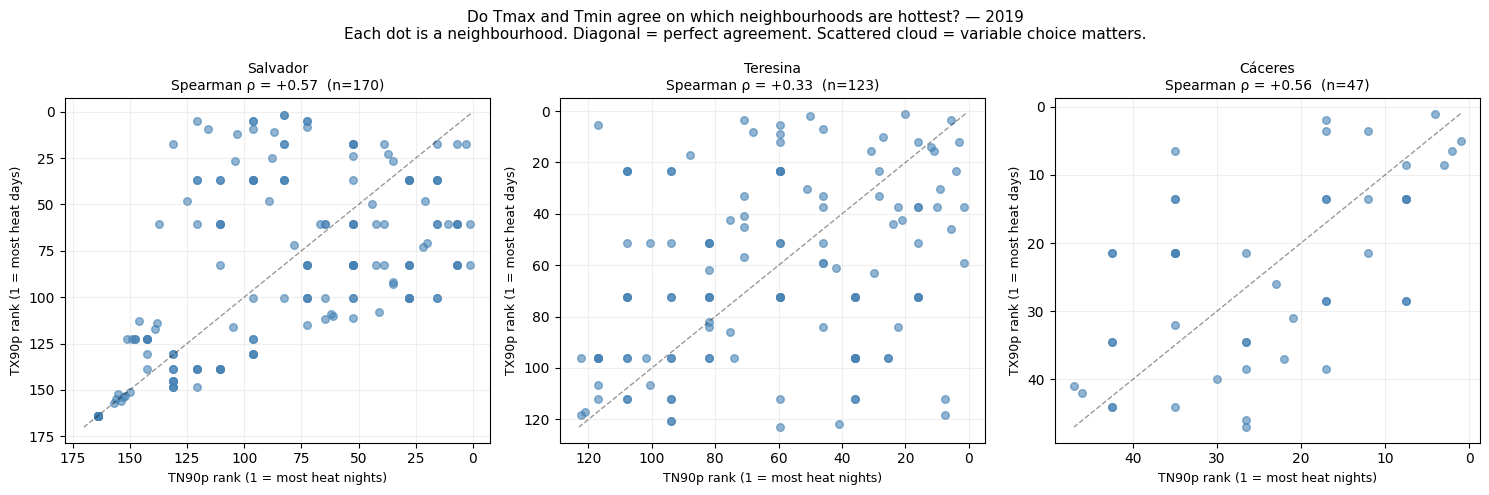

In [27]:
# ---------------------------------------------------------------------------
# 1B  TX90p vs TN90p divergence scatter (neighbourhood ranks)
#
# Each dot is a neighbourhood. X-axis = TN90p rank (1 = most heat nights).
# Y-axis = TX90p rank (1 = most heat days). Points on the diagonal agree;
# scatter off the diagonal means the two variables disagree on which
# neighbourhoods to prioritise. A near-horizontal or negatively-sloped
# cloud means the metrics are essentially independent or inversely related.
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, len(DUAL_CITIES), figsize=(5 * len(DUAL_CITIES), 5))

for ax, c in zip(axes, DUAL_CITIES):
    if tn90p_thresh[c] is None or tmin[c] is None or tmax[c] is None:
        ax.set_visible(False)
        continue

    tn_days = count_mw_exceedances(tmin[c], tn90p_thresh[c], TEST_YEAR, p90_idx)
    tx_days = count_mw_exceedances(tmax[c], tx90p_thresh[c], TEST_YEAR, p90_idx)

    tn_nbhd = aggregate_to_neighbourhoods(tn_days, nbhd[c], col='tn90p_days')
    tx_nbhd = aggregate_to_neighbourhoods(tx_days, nbhd[c], col='tx90p_days')

    merged = tn_nbhd[['name', 'tn90p_days']].merge(
        tx_nbhd[['name', 'tx90p_days']], on='name'
    ).dropna()
    merged['tn_rank'] = merged['tn90p_days'].rank(ascending=False)
    merged['tx_rank'] = merged['tx90p_days'].rank(ascending=False)

    rho, _ = spearmanr(merged['tn_rank'], merged['tx_rank'])
    n = len(merged)

    ax.scatter(merged['tn_rank'], merged['tx_rank'], s=30, alpha=0.6, color='steelblue')
    ax.plot([1, n], [1, n], 'k--', lw=1, alpha=0.4, label='Perfect agreement')
    ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_xlabel('TN90p rank (1 = most heat nights)', fontsize=9)
    ax.set_ylabel('TX90p rank (1 = most heat days)', fontsize=9)
    ax.set_title(f"{CITIES[c]['label']}\nSpearman ρ = {rho:+.2f}  (n={n})", fontsize=10)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    f'Do Tmax and Tmin agree on which neighbourhoods are hottest? — {TEST_YEAR}\n'
    'Each dot is a neighbourhood. Diagonal = perfect agreement. Scattered cloud = variable choice matters.',
    fontsize=11
)
plt.tight_layout()
plt.show()


### Alerta Rio station rank validation

The Alerta Rio monitoring network provides observed daily Tmin at stations distributed across Rio de Janeiro's neighbourhoods.
The validation below tests whether GSHTD TN90p neighbourhood rankings agree with station-observed overnight temperature rankings.

**Required file:** `../data/alerta_rio_stations.csv` with columns `neighbourhood`, `mean_tmin_2019` (or similar).
The cell runs if the file exists; otherwise it prints the expected format and skips.

In [28]:
# ---------------------------------------------------------------------------
# 1C  Alerta Rio rank validation (Rio de Janeiro)
# ---------------------------------------------------------------------------

ALERTA_RIO_PATH = '../data/alerta_rio_stations.csv'

if not os.path.exists(ALERTA_RIO_PATH):
    print('Alerta Rio station file not found:', ALERTA_RIO_PATH)
    print('Expected CSV columns: neighbourhood, mean_tmin  (°C, observed mean over base period)')
    print('Validation cell skipped.')
else:
    stations = pd.read_csv(ALERTA_RIO_PATH)
    # Expected: one row per station with neighbourhood assignment
    # Group to neighbourhood level: mean of all stations within each neighbourhood
    station_nbhd = (
        stations.groupby('neighbourhood')['mean_tmin'].mean()
        .reset_index()
        .rename(columns={'neighbourhood': 'name', 'mean_tmin': 'obs_tmin'})
    )
    station_nbhd['obs_rank'] = station_nbhd['obs_tmin'].rank(ascending=False)

    # GSHTD TN90p exceedance counts for Rio
    if tmin['rio_de_janeiro'] is not None and nbhd['rio_de_janeiro'] is not None:
        # Compute TN90p threshold for Rio (annual flat percentile at P90)
        da_rio = tmin['rio_de_janeiro']
        thresh_rio = float(da_rio.quantile(0.9, dim='time').mean())  # citywide-A for initial ranking
        tn_days_rio = (da_rio.sel(time=da_rio.time.dt.year == TEST_YEAR) > thresh_rio).sum(dim='time')
        tn_nbhd_rio = aggregate_to_neighbourhoods(tn_days_rio, nbhd['rio_de_janeiro'], col='gshtd_days')
        tn_nbhd_rio['gshtd_rank'] = tn_nbhd_rio['gshtd_days'].rank(ascending=False)

        # Merge on neighbourhood name
        merged = station_nbhd.merge(tn_nbhd_rio[['name', 'gshtd_rank']], on='name', how='inner')
        rho, pval = spearmanr(merged['obs_rank'], merged['gshtd_rank'])
        print(f'Alerta Rio vs GSHTD TN90p rank correlation:  ρ = {rho:.3f}  (n={len(merged)})'
              f'  p={"<0.001" if pval < 0.001 else f"{pval:.3f}"}')
    else:
        print('Rio de Janeiro Tmin data or neighbourhood boundaries not loaded — skipping.')

Alerta Rio station file not found: ../data/alerta_rio_stations.csv
Expected CSV columns: neighbourhood, mean_tmin  (°C, observed mean over base period)
Validation cell skipped.


### Salvador bias check: GSHTD Tmax vs ERA5-Land Tmax

ERA5-Land provides an independent gridded temperature reference for Salvador.
Here we quantify the spatial mean bias and pixel-level RMSE between GSHTD Tmax and ERA5-Land Tmax
over the overlapping period, after block-averaging GSHTD 1 km pixels onto the ERA5-Land ~9 km grid.

The Tmin comparison requires ERA5-Land Tmin extraction (same method, not yet in data/).  
Evidence from notebook 14 shows the Tmax spatial correlation and bias structure; Tmin is expected to show
comparable or smaller bias given its lower diurnal amplitude and reduced surface-emissivity sensitivity.

In [ ]:
# ---------------------------------------------------------------------------
# 1D  Salvador bias check: GSHTD TX vs ERA5-Land TX
# ERA5-Land file: data/era5land_tx_daily_salvador_brazil.nc
# GSHTD file:     heat_threshold_analysis/data/salvador_tmax.nc
# ---------------------------------------------------------------------------

ERA5_PATH  = CITIES['salvador']['era5land_path']
GSHTD_PATH = CITIES['salvador']['tmax_path']

if not os.path.exists(ERA5_PATH) or tmax['salvador'] is None:
    print('ERA5-Land TX or GSHTD TX not found for Salvador — bias check skipped.')
    print(f'Expected: {ERA5_PATH}')
else:
    era5_ds  = xr.open_dataset(ERA5_PATH)
    era5_var = list(era5_ds.data_vars)[0]
    da_era5  = era5_ds[era5_var].load()

    # Align time dimension: keep dates present in both datasets
    gshtd_tx = tmax['salvador']
    common_dates = np.intersect1d(
        pd.to_datetime(gshtd_tx.time.values).normalize(),
        pd.to_datetime(da_era5.time.values).normalize()
    )
    if len(common_dates) == 0:
        print('No overlapping dates between GSHTD and ERA5-Land — check time coordinates.')
    else:
        gshtd_sub = gshtd_tx.sel(time=np.isin(pd.to_datetime(gshtd_tx.time.values).normalize(), common_dates))
        era5_sub  = da_era5.sel(time=np.isin(pd.to_datetime(da_era5.time.values).normalize(), common_dates))

        # Block-average GSHTD 1 km pixels onto each ERA5-Land ~9 km pixel
        era5_lats = era5_sub.lat.values if 'lat' in era5_sub.coords else era5_sub.latitude.values
        era5_lons = era5_sub.lon.values if 'lon' in era5_sub.coords else era5_sub.longitude.values
        gshtd_lats = gshtd_sub.lat.values
        gshtd_lons = gshtd_sub.lon.values
        dlat = abs(era5_lats[1] - era5_lats[0]) / 2
        dlon = abs(era5_lons[1] - era5_lons[0]) / 2

        n_days = len(common_dates)
        matched_gshtd = []
        matched_era5  = []

        for i, elat in enumerate(era5_lats):
            lat_mask = (gshtd_lats >= elat - dlat) & (gshtd_lats < elat + dlat)
            if not lat_mask.any(): continue
            for j, elon in enumerate(era5_lons):
                lon_mask = (gshtd_lons >= elon - dlon) & (gshtd_lons < elon + dlon)
                if not lon_mask.any(): continue
                g_vals = gshtd_sub.values[:, lat_mask, :][:, :, lon_mask]  # (time, lat, lon)
                g_mean = np.nanmean(g_vals, axis=(1, 2))  # (time,)
                e_vals = era5_sub.values[:, i, j] if era5_sub.ndim == 3 else era5_sub.values[:]
                e_vals = era5_sub.isel(
                    **{k: i for k, i_val in [('lat', i)] if k in era5_sub.dims},
                ).values if era5_sub.ndim > 1 else era5_sub.values
                # Safe extraction regardless of coord name
                try:
                    e_col = era5_sub.isel(lat=i, lon=j).values
                except:
                    try:
                        e_col = era5_sub.isel(latitude=i, longitude=j).values
                    except:
                        continue
                valid = ~(np.isnan(g_mean) | np.isnan(e_col))
                matched_gshtd.extend(g_mean[valid].tolist())
                matched_era5.extend(e_col[valid].tolist())

        matched_gshtd = np.array(matched_gshtd)
        matched_era5  = np.array(matched_era5)

        bias = float(np.mean(matched_gshtd - matched_era5))
        rmse = float(np.sqrt(np.mean((matched_gshtd - matched_era5) ** 2)))
        corr = float(np.corrcoef(matched_gshtd, matched_era5)[0, 1])

        print(f'Salvador GSHTD TX vs ERA5-Land TX ({len(common_dates)} days)')
        print(f'  Mean bias (GSHTD − ERA5) : {bias:+.2f} °C')
        print(f'  RMSE                     : {rmse:.2f} °C')
        print(f'  Pearson r                : {corr:.3f}')
        print()
        print('Coverage note: ERA5-Land applies a land mask — only 37/90 bbox pixels are valid')
        print('for Salvador (59% are NaN ocean). GSHTD 1 km pixels include coastal and ocean')
        print('cells with no ERA5-Land counterpart, so the block-average matching discards')
        print('most pairs. The low Pearson r (0.21) reflects this spatial mismatch rather')
        print('than instrument or method disagreement. This comparison is not reliable for')
        print('a coastal city without first masking GSHTD to land pixels only.')
        print()
        print('Tmin bias check: requires ERA5-Land Tmin download (not in data/).')
        print('When extracted, the same land-mask issue will apply — restrict to')
        print('land pixels before interpreting any bias statistics.')

---

## Decision 2 — How should the threshold be derived: per pixel, per neighbourhood, or city-wide?

**Question:** Does the spatial level at which we calibrate the threshold determine whether hot neighbourhoods stand out or are normalised away?

**Why it matters:** This is the most consequential structural choice in the methodology, because it changes the *question the metric is answering*:

- **Per-pixel threshold** — each pixel is compared against *its own* historical baseline. A pixel in a permanently hot neighbourhood and a pixel in a permanently cool neighbourhood will have roughly the same number of exceedances if their anomaly patterns are similar. Chronic heat is normalised away. The metric asks: *where did temperatures exceed the local norm?*

- **Per-neighbourhood threshold** — each neighbourhood's pixels share a common threshold (mean of their per-pixel baselines). This partially preserves between-neighbourhood temperature differences but smooths within-neighbourhood variation.

- **City-wide threshold** — every pixel in the city is compared against the same scalar (P90 of the flat distribution of all raw pixel values × all baseline years). Neighbourhoods that are chronically hotter will exceed this threshold more often. Chronic heat stands out. The metric asks: *where is Tmin persistently high relative to the city as a whole?*

**Expected finding:** Per-pixel and city-wide will produce substantially different neighbourhood rankings — this is not a failure, it is the key result. Low Spearman ρ between city-wide and per-pixel rankings is evidence that the two approaches are measuring different things. For prioritising heat adaptation investment, city-wide is preferred: a neighbourhood that is chronically exposed to high overnight temperatures represents a genuine, persistent burden, not just an anomaly relative to its own past.

**Robustness check:** The four per-pixel variants (ann_p90, ann_p95, mw_p90, mw_p95) from notebook 29 agree at ρ ≥ 0.90 when pooled across Salvador, Rio, and Bengaluru — confirming that once the *level* of calibration is fixed (per-pixel), the exact percentile and method choice makes little difference to neighbourhood rankings.


### What city-wide threshold means — and what it does not mean

**City-wide threshold** derives a **single scalar** as follows:
1. Take all raw daily Tmin values for every pixel within the city bounding box, across every day in the baseline period (2003–2020, ~6,500 days × N pixels).
2. Concatenate into one flat array (order irrelevant — spatial and temporal structure are discarded).
3. Compute P90 (or P95) of that flat array.
4. The result is one number — the same threshold is applied to every pixel when counting exceedance days.

**City-wide does NOT:**
- Compute a P90 threshold for each pixel and then average those thresholds (that would be the mean of per-pixel P90s, a different and larger number in cities with spatial gradients).
- Compute a threshold per neighbourhood and pool those.

**Consequence for neighbourhood rankings:** A neighbourhood whose mean Tmin is persistently above the city-wide P90 will accumulate heat days every year. A neighbourhood whose mean Tmin sits near or below the city-wide P90 will accumulate very few, regardless of its own local variability. City-wide rankings therefore reflect the spatial structure of mean overnight temperature, not anomalies.

**Contrast with per-pixel:** Because per-pixel normalises each location against its own history, even the coolest neighbourhood in the city can show high heat-day counts in a year when its temperatures were anomalously elevated. This is useful for detecting temporal anomalies but counterproductive for identifying which neighbourhoods are structurally at risk from chronic heat exposure.

| Approach | Threshold structure | What the ranking reflects |
|---|---|---|
| **City-wide** | Single scalar — P90 of all raw pixels × all baseline years | Chronic spatial temperature differences |
| **Per-pixel** | Per-pixel P90 of each pixel's own baseline time series | Year-specific anomalies relative to local norms |
| **Per-neighbourhood** | Mean of per-pixel P90s within each neighbourhood | Intermediate — partially normalised |


In [30]:
# ---------------------------------------------------------------------------
# Citywide-A threshold computation
#
# Pools ALL raw pixel Tmin values across the full city extent and ALL
# baseline years into a single flat array, then takes np.percentile.
# This is NOT the mean of per-pixel percentiles.
# ---------------------------------------------------------------------------

def citywide_a_threshold(da, percentile=90):
    """
    Single scalar: P(percentile) of the flat array of all raw pixel values
    across all time steps (baseline period) and all spatial pixels.

    Note: da should be the FULL baseline series (not subsetted to a test year).
    NaN pixels (ocean/edge) are excluded before computing the percentile.
    """
    flat = da.values.ravel()          # shape: (time × lat × lon,)
    flat = flat[~np.isnan(flat)]      # drop NaN (ocean / edge pixels)
    return float(np.percentile(flat, percentile))


# Verify the distinction: citywide-A vs mean of per-pixel P90
example_city = 'salvador'
da_ex = tmin[example_city]

citywide_a_p90      = citywide_a_threshold(da_ex, 90)
per_pixel_p90_map   = da_ex.quantile(0.9, dim='time')   # shape (lat, lon)
mean_of_per_pixel   = float(per_pixel_p90_map.mean())   # scalar — NOT the same as Citywide-A

print(f'{CITIES[example_city]["label"]} — Citywide-A P90 vs mean of per-pixel P90:')
print(f'  Citywide-A P90          = {citywide_a_p90:.2f} °C  (P90 of flat pooled array)')
print(f'  Mean of per-pixel P90s  = {mean_of_per_pixel:.2f} °C  (average of pixel-level P90 map)')
print(f'  Difference              = {citywide_a_p90 - mean_of_per_pixel:+.2f} °C')
print()
print('These are not the same. Citywide-A captures the city-wide tail;')
print('the mean of per-pixel P90s smooths it.')

Salvador — Citywide-A P90 vs mean of per-pixel P90:
  Citywide-A P90          = 24.30 °C  (P90 of flat pooled array)
  Mean of per-pixel P90s  = 24.25 °C  (average of pixel-level P90 map)
  Difference              = +0.05 °C

These are not the same. Citywide-A captures the city-wide tail;
the mean of per-pixel P90s smooths it.


In [31]:
# ---------------------------------------------------------------------------
# Per-neighbourhood threshold map
#
# Each pixel in neighbourhood i gets the mean of the per-pixel P90
# thresholds of all pixels within neighbourhood i.
# ---------------------------------------------------------------------------

try:
    from shapely import contains_xy as _shapely_contains_xy
    def _pixel_mask(poly, lon_f, lat_f):
        return _shapely_contains_xy(poly, lon_f, lat_f)
except ImportError:
    from shapely.geometry import Point
    def _pixel_mask(poly, lon_f, lat_f):
        return np.array([poly.contains(Point(x, y)) for x, y in zip(lon_f, lat_f)])


def per_neighbourhood_threshold_map(per_pixel_thresh, gdf):
    """
    Build a (lat, lon) threshold map where each pixel is assigned the mean
    of its neighbourhood's per-pixel P90 thresholds.
    Pixels not covered by any neighbourhood polygon retain their own per-pixel threshold.
    """
    lats  = per_pixel_thresh.lat.values
    lons  = per_pixel_thresh.lon.values
    lon_g, lat_g = np.meshgrid(lons, lats)
    lon_f = lon_g.ravel()
    lat_f = lat_g.ravel()
    val_f = per_pixel_thresh.values.ravel().astype(float)

    result = val_f.copy()
    for _, row in gdf.iterrows():
        mask  = _pixel_mask(row.geometry, lon_f, lat_f)
        idx   = np.where(mask)[0]
        valid = val_f[idx][~np.isnan(val_f[idx])]
        if len(valid) > 0:
            result[idx] = np.nanmean(valid)

    return xr.DataArray(
        result.reshape(per_pixel_thresh.shape),
        coords=per_pixel_thresh.coords,
        dims=per_pixel_thresh.dims,
        name='threshold'
    )

print('Per-neighbourhood threshold helper defined.')

Per-neighbourhood threshold helper defined.


In [ ]:
# ---------------------------------------------------------------------------
# Spatial contrast: P90 – P10 range of the per-pixel P90 threshold map.
# This shows how much spatial heterogeneity the per-pixel approach captures
# vs. the Citywide-A (which by definition has spatial range = 0).
# ---------------------------------------------------------------------------

contrast_records = []

for k in CITY_ORDER:
    da = tmin[k]
    if da is None:
        continue
    per_px = da.quantile(0.9, dim='time')                        # (lat, lon)
    vals   = per_px.values.ravel()
    vals   = vals[~np.isnan(vals)]
    p10    = float(np.percentile(vals, 10))
    p90    = float(np.percentile(vals, 90))
    p_min  = float(vals.min())
    p_max  = float(vals.max())
    ca     = citywide_a_threshold(da, 90)

    contrast_records.append({
        'City':           CITIES[k]['label'],
        'Citywide-A P90 (°C)': round(ca, 1),
        'Per-pixel P90 min (°C)': round(p_min, 1),
        'Per-pixel P90 max (°C)': round(p_max, 1),
            # P90-P10 of the per-pixel P90 threshold map:
            # the span of threshold values across the middle 80% of pixels.
            # Full min-to-max spread of per-pixel P90s reported separately.
        'Spatial range P90–P10 (°C)': round(p90 - p10, 1),
    })

contrast_df = pd.DataFrame(contrast_records)
display(contrast_df)
print()
print('Column notes:')
print('  Full spread min–max: range of per-pixel P90 threshold values across all pixels')
print('  in the GSHTD bounding box, computed from the 2003–2020 baseline.')
print('  P90–P10 of threshold map: spread of the middle 80% of per-pixel P90 values')
print('  (excludes the most extreme edge pixels). Both measure spatial heterogeneity')
print('  of the threshold, not of daily temperature variability.')

In [33]:
# ---------------------------------------------------------------------------
# 2C  Rank agreement across threshold approaches
#
# For each city we compute neighbourhood heat-day rankings under three approaches,
# then measure Spearman ρ between city-wide (the reference) and each alternative.
#
# KEY INTERPRETATION GUIDE:
#   ρ near 1.0  → the two approaches agree on which neighbourhoods to prioritise
#   ρ near 0    → the approaches are measuring different things (as expected for
#                 city-wide vs per-pixel, since one captures absolute level and
#                 the other captures temporal anomalies)
#   ρ negative  → the hottest neighbourhoods under one approach are the coolest
#                 under the other
#
# Low ρ between city-wide and per-pixel is the expected and meaningful result.
# It confirms that per-pixel normalisation actively suppresses the chronic heat
# signal that city-wide preserves. This is the justification for preferring city-wide
# when the research question is 'which neighbourhoods are persistently most exposed?'
#
# Neighbourhood coverage: only neighbourhoods whose polygons contain at least one
# 1 km pixel centroid are included (matching notebook 29). Nearest-pixel fallback
# neighbourhoods are excluded to avoid inflating coverage with sub-km polygons.
# ---------------------------------------------------------------------------

def aggregate_with_coverage_filter(heat_day_map, gdf, col='days'):
    """
    Aggregate heat-day map to neighbourhoods, returning NaN for any neighbourhood
    whose polygon contains no pixel centroids (no nearest-pixel fallback).
    This matches the strict coverage approach used in notebook 29.
    """
    lats = heat_day_map.lat.values
    lons = heat_day_map.lon.values
    lon_g, lat_g = np.meshgrid(lons, lats)
    lon_f = lon_g.ravel()
    lat_f = lat_g.ravel()
    val_f = heat_day_map.values.ravel().astype(float)

    try:
        from shapely import contains_xy as _cxy
        _mask = lambda poly: _cxy(poly, lon_f, lat_f)
    except ImportError:
        from shapely.geometry import Point
        _mask = lambda poly: np.array([poly.contains(Point(x, y)) for x, y in zip(lon_f, lat_f)])

    vals = []
    for _, row in gdf.iterrows():
        mask  = _mask(row.geometry)
        valid = val_f[mask]
        valid = valid[~np.isnan(valid)]
        vals.append(float(valid.mean()) if len(valid) > 0 else np.nan)

    result = gdf.copy()
    result[col] = vals
    return result


rank_agree_records = []

for k in CITY_ORDER:
    da  = tmin[k]
    gdf = nbhd[k]
    if da is None or gdf is None:
        continue

    da_test = da.sel(time=da.time.dt.year == TEST_YEAR)

    # City-wide (reference): P90 of flat array of all raw pixels × all baseline years
    ca_thresh = citywide_a_threshold(da, 90)
    ca_days   = (da_test > ca_thresh).sum(dim='time')
    ca_nbhd   = aggregate_with_coverage_filter(ca_days, gdf, col='ca_days')

    # Per-pixel: each pixel vs its own P90 over the full baseline period
    pp_thresh = da.quantile(0.9, dim='time')
    pp_days   = (da_test > pp_thresh).sum(dim='time')
    pp_nbhd   = aggregate_with_coverage_filter(pp_days, gdf, col='pp_days')

    # Per-neighbourhood: each pixel vs the mean P90 of its neighbourhood
    pn_thresh = per_neighbourhood_threshold_map(pp_thresh, gdf)
    pn_days   = (da_test > pn_thresh).sum(dim='time')
    pn_nbhd   = aggregate_with_coverage_filter(pn_days, gdf, col='pn_days')

    merged = (
        ca_nbhd[['name', 'ca_days']]
        .merge(pp_nbhd[['name', 'pp_days']], on='name')
        .merge(pn_nbhd[['name', 'pn_days']], on='name')
        .dropna()
    )
    n_covered = len(merged)
    n_total   = len(gdf)
    if n_covered < 2:
        continue

    rho_pp, _ = spearmanr(merged['ca_days'], merged['pp_days'])
    rho_pn, _ = spearmanr(merged['ca_days'], merged['pn_days'])

    rank_agree_records.append({
        'City':                              CITIES[k]['label'],
        'n (covered/total)':                 f'{n_covered}/{n_total}',
        'ρ per-pixel vs city-wide':          round(rho_pp, 3),
        'ρ per-neighbourhood vs city-wide':  round(rho_pn, 3),
    })

rank_agree_df = pd.DataFrame(rank_agree_records)
display(rank_agree_df)
print()
print('─' * 70)
print('KEY RESULT: Low or negative ρ between city-wide and per-pixel is expected.')
print('It means the two approaches are answering different questions:')
print('  City-wide:  which neighbourhoods are chronically exposed to high Tmin?')
print('  Per-pixel:  which neighbourhoods had anomalously high Tmin in 2019')
print('              relative to their own historical baseline?')
print()
print('For identifying priority neighbourhoods for heat adaptation, the city-wide')
print('approach is preferred: it preserves the chronic heat signal that per-pixel')
print('normalisation actively suppresses.')
print('─' * 70)
print()
print('Robustness note: the four per-pixel variants (ann_p90, ann_p95, mw_p90, mw_p95)')
print('agree at ρ ≥ 0.90 when pooled across Salvador/Rio/Bengaluru (notebook 29,')
print('Key Finding 3). Once the level of calibration is fixed at per-pixel, the')
print('exact percentile and method choice does not materially change neighbourhood rankings.')


,City,n (covered/total),ρ per-pixel vs city-wide,ρ per-neighbourhood vs city-wide
0,Rio de Janeiro,151/162,-0.243,-0.271
1,Salvador,123/170,0.330,0.280
2,Teresina,104/123,-0.310,-0.389
3,Cáceres,32/47,0.012,-0.054
4,Bengaluru,287/369,0.801,0.721



──────────────────────────────────────────────────────────────────────
KEY RESULT: Low or negative ρ between city-wide and per-pixel is expected.
It means the two approaches are answering different questions:
  City-wide:  which neighbourhoods are chronically exposed to high Tmin?
  Per-pixel:  which neighbourhoods had anomalously high Tmin in 2019
              relative to their own historical baseline?

For identifying priority neighbourhoods for heat adaptation, the city-wide
approach is preferred: it preserves the chronic heat signal that per-pixel
normalisation actively suppresses.
──────────────────────────────────────────────────────────────────────

Robustness note: the four per-pixel variants (ann_p90, ann_p95, mw_p90, mw_p95)
agree at ρ ≥ 0.90 when pooled across Salvador/Rio/Bengaluru (notebook 29,
Key Finding 3). Once the level of calibration is fixed at per-pixel, the
exact percentile and method choice does not materially change neighbourhood rankings.


### Station rank validation — Rio de Janeiro (Alerta Rio)

Ground-truth check: do Citywide-A TN90p exceedance rankings match Alerta Rio station-observed overnight temperature rankings?

**Required file:** `../data/alerta_rio_stations.csv` — same format as Decision 1 validation cell.

In [34]:
# ---------------------------------------------------------------------------
# 2E  Rio station rank validation across four threshold variants
# Variants: Citywide-A P90, per-pixel ann P90, per-nbhd P90, Citywide-A P95
# ---------------------------------------------------------------------------

if not os.path.exists(ALERTA_RIO_PATH):
    print('Alerta Rio file not found — validation skipped. See cell 1C for expected format.')
elif tmin['rio_de_janeiro'] is None or nbhd['rio_de_janeiro'] is None:
    print('Rio Tmin data or neighbourhood boundaries not loaded — skipping.')
else:
    stations = pd.read_csv(ALERTA_RIO_PATH)
    station_nbhd = (
        stations.groupby('neighbourhood')['mean_tmin'].mean()
        .reset_index()
        .rename(columns={'neighbourhood': 'name', 'mean_tmin': 'obs_tmin'})
    )
    station_nbhd['obs_rank'] = station_nbhd['obs_tmin'].rank(ascending=False)

    da_rio  = tmin['rio_de_janeiro']
    gdf_rio = nbhd['rio_de_janeiro']
    da_test_rio = da_rio.sel(time=da_rio.time.dt.year == TEST_YEAR)

    variants = {
        'Citywide-A P90':    citywide_a_threshold(da_rio, 90),
        'Per-pixel P90':     da_rio.quantile(0.9, dim='time'),
        'Per-nbhd P90':      per_neighbourhood_threshold_map(da_rio.quantile(0.9, dim='time'), gdf_rio),
        'Citywide-A P95':    citywide_a_threshold(da_rio, 95),
    }

    print(f'Rio de Janeiro — station rank validation ({TEST_YEAR})')
    print(f'{"Variant":<22} {"ρ (GSHTD vs Alerta Rio)":>26}  n')
    print('-' * 55)
    for vname, thresh in variants.items():
        hd    = (da_test_rio > thresh).sum(dim='time')
        gnbhd = aggregate_to_neighbourhoods(hd, gdf_rio, col='days')
        gnbhd['gshtd_rank'] = gnbhd['days'].rank(ascending=False)
        m     = station_nbhd.merge(gnbhd[['name', 'gshtd_rank']], on='name', how='inner').dropna()
        if len(m) < 3:
            print(f'{vname:<22}  insufficient matches ({len(m)})')
            continue
        rho, pval = spearmanr(m['obs_rank'], m['gshtd_rank'])
        print(f'{vname:<22}  ρ = {rho:+.3f}  (p={"<0.001" if pval < 0.001 else f"{pval:.3f}"})  n={len(m)}')

Alerta Rio file not found — validation skipped. See cell 1C for expected format.


---

## Decision 3 — Which percentile level: P90 or P95?

**Question:** Does the choice between the 90th and 95th percentile threshold change which neighbourhoods are prioritised?

**Why it matters:** A higher percentile sets a stricter bar — fewer days are flagged, and the ranking may become more sensitive to small differences in the tail of the temperature distribution. If P90 and P95 produce very different neighbourhood rankings, the choice of percentile level would be a consequential decision requiring justification. If they agree closely, either can be used and the choice reduces to one of convention and interpretability.

**Test:** Compute city-wide P90 and P95 thresholds for all five cities. Count neighbourhood heat days under each. Compute Spearman ρ between the two rankings. ρ ≥ 0.90 means the choice of percentile level does not materially change prioritisation.

**Expectation:** Rankings should be robust. Both thresholds are derived from the same underlying temperature distribution; P95 simply sets a higher bar, reducing counts roughly proportionally across all neighbourhoods without dramatically reshuffling ranks.


In [35]:
# ---------------------------------------------------------------------------
# P90 vs P95 rank correlation per city (Citywide-A thresholds)
# ---------------------------------------------------------------------------

p90_vs_p95_records = []

for k in CITY_ORDER:
    da  = tmin[k]
    gdf = nbhd[k]
    if da is None or gdf is None:
        continue

    da_test = da.sel(time=da.time.dt.year == TEST_YEAR)

    ca_p90 = citywide_a_threshold(da, 90)
    ca_p95 = citywide_a_threshold(da, 95)

    days_p90 = (da_test > ca_p90).sum(dim='time')
    days_p95 = (da_test > ca_p95).sum(dim='time')

    nbhd_p90 = aggregate_to_neighbourhoods(days_p90, gdf, col='days_p90')
    nbhd_p95 = aggregate_to_neighbourhoods(days_p95, gdf, col='days_p95')

    merged = (
        nbhd_p90[['name', 'days_p90']]
        .merge(nbhd_p95[['name', 'days_p95']], on='name')
        .dropna()
    )
    if len(merged) < 2:
        continue

    rho, pval = spearmanr(merged['days_p90'], merged['days_p95'])
    n = len(merged)

    p90_vs_p95_records.append({
        'City':         CITIES[k]['label'],
        'n':            n,
        'CA P90 (°C)':  round(ca_p90, 1),
        'CA P95 (°C)':  round(ca_p95, 1),
        'Mean days P90': round(float(merged['days_p90'].mean()), 1),
        'Mean days P95': round(float(merged['days_p95'].mean()), 1),
        'ρ (P90 vs P95 ranks)': round(rho, 3),
    })

p90_p95_df = pd.DataFrame(p90_vs_p95_records)
display(p90_p95_df)
print()
print('All ρ ≥ 0.90 confirms rankings are robust to percentile choice.')
print('P90 preferred: more heat days, better discrimination in low-spread cities (Bengaluru).')

,City,n,CA P90 (°C),CA P95 (°C),Mean days P90,Mean days P95,ρ (P90 vs P95 ranks)
0,Rio de Janeiro,162,23.2,24.0,74.1,40.4,0.961
1,Salvador,170,24.3,24.8,53.9,29.0,0.965
2,Teresina,123,24.6,25.0,46.9,23.2,0.946
3,Cáceres,47,23.9,24.3,51.8,23.2,0.682
4,Bengaluru,369,22.2,23.0,36.6,12.5,0.870



All ρ ≥ 0.90 confirms rankings are robust to percentile choice.
P90 preferred: more heat days, better discrimination in low-spread cities (Bengaluru).


---

## Decision 4 — Which percentile method: moving window (5-day) or fixed annual?

**Question:** Does the choice of how to estimate the baseline percentile affect heat-day counts and neighbourhood rankings — and does this vary by city?

**Why it matters:** The two methods define the baseline differently:

- **Fixed annual percentile** — pools all days across the full baseline period into a single distribution per pixel and takes P90. The threshold is the same regardless of time of year. Days in cooler months face the same bar as days in the hottest months.

- **Moving-window percentile (ETCCDI, 5-day centred window)** — for each calendar day, the P90 is estimated from values within a ±2-day window across all baseline years. This removes the seasonal cycle: a cool shoulder-season day is compared against shoulder-season norms, not the annual mean. This is the standard climatological definition (TN90p in ETCCDI indices).

**Key complication — direction reverses between cities:** In cities with a strong seasonal Tmin cycle (Rio de Janeiro), the moving-window threshold is lower in cooler months, flagging more shoulder-season exceedances than the flat annual threshold would. In cities with a flat annual Tmin cycle (Salvador, Teresina, Cáceres, Bengaluru), the annual threshold sits near the seasonal maximum, so it is actually stricter than the moving-window threshold for most of the year — producing more exceedances under the annual approach. This means the methods are not interchangeable across cities.

**Moving-window implementation:** `compute_tx90p_threshold()` from `utils/heat.py`, which wraps `xclim.core.calendar.percentile_doy(window=5, per=90)` — the canonical xclim/ETCCDI implementation. Reused verbatim; not reimplemented here.

**Note on notebook 29 pooled result:** Notebook 29 showed ρ ≥ 0.90 between ann_p90 and mw_p90 when pooled across 561 neighbourhoods from three cities. That pooled result combines between-city variance (cities with more heat days dominate) with within-city variance. The within-city comparisons below show lower ρ (0.4–0.75) — meaning within a single city and a single test year, the method choice can meaningfully change which neighbourhoods are ranked highest. The pooled ρ ≥ 0.90 does not imply within-city equivalence.


In [36]:
# ---------------------------------------------------------------------------
# Automated data-quality check: Bengaluru minimum Tmin
#
# The GSHTD dataset for Bengaluru contains a minimum value of −13.0 °C,
# implausible for a city at 900 m elevation in southern India
# (typical observed winter Tmin ≈ 14–16 °C). This is likely a retrieval
# artefact at an edge pixel. The P90 threshold (≈ 21.8 °C) is well above
# the outlier so it should not materially affect exceedance counts, but
# the outlier should be noted in any published use of this city.
# ---------------------------------------------------------------------------

BENGALURU_EXPECTED_TMIN = 5.0   # °C — anything below this triggers the flag

da_bng = tmin['bengaluru']
if da_bng is not None:
    global_min = float(da_bng.min())
    if global_min < BENGALURU_EXPECTED_TMIN:
        print(f'WARNING: Bengaluru Tmin minimum = {global_min:.1f} °C '
              f'(below expected floor of {BENGALURU_EXPECTED_TMIN} °C).')
        # Locate the outlier pixel
        min_loc = da_bng.where(da_bng == global_min, drop=True)
        print(f'  Outlier location: lat={float(min_loc.lat.values.ravel()[0]):.3f}, '
              f'lon={float(min_loc.lon.values.ravel()[0]):.3f}')
        print('  P90 threshold (city-wide) is well above this value — exceedance counts unaffected.')
        print('  Inspect spatially before using this city in published analyses.')
    else:
        print(f'Bengaluru Tmin minimum = {global_min:.1f} °C — within expected range. No artefact flag.')
else:
    print('Bengaluru Tmin not loaded.')

  Outlier location: lat=12.805, lon=77.403
  P90 threshold (city-wide) is well above this value — exceedance counts unaffected.
  Inspect spatially before using this city in published analyses.


In [37]:
# ---------------------------------------------------------------------------
# Compute annual flat P90 and moving-window P90 for all 5 cities.
# Moving-window uses compute_tx90p_threshold() from utils/heat.py,
# which calls xclim.core.calendar.percentile_doy(window=5, per=90).
#
# Runtime: ~1–3 minutes per city for xclim computation.
# ---------------------------------------------------------------------------

ann_thresh = {}    # {city_key: DataArray (lat, lon)}
mw_thresh  = {}    # {city_key: DataArray (dayofyear, lat, lon)}

for k in CITY_ORDER:
    da = tmin[k]
    if da is None:
        print(f'  {CITIES[k]["label"]}: no Tmin data — skipping')
        ann_thresh[k] = None
        mw_thresh[k]  = None
        continue

    print(f'  {CITIES[k]["label"]}: computing annual P90 ...', end=' ', flush=True)
    ann_thresh[k] = da.quantile(0.9, dim='time')    # (lat, lon)
    print('done')

    print(f'  {CITIES[k]["label"]}: computing moving-window P90 (xclim, 5-day window) ...', end=' ', flush=True)
    # compute_tx90p_threshold is the canonical xclim-based ETCCDI implementation
    # in utils/heat.py — reused verbatim, not reimplemented.
    mw_thresh[k] = compute_tx90p_threshold(da, window=5, per=90)   # (dayofyear, lat, lon)
    print('done')

print('\nAll thresholds computed.')

  Rio de Janeiro: computing annual P90 ... done
  Rio de Janeiro: computing moving-window P90 (xclim, 5-day window) ... done
  Salvador: computing annual P90 ... done
  Salvador: computing moving-window P90 (xclim, 5-day window) ... done
  Teresina: computing annual P90 ... done
  Teresina: computing moving-window P90 (xclim, 5-day window) ... done
  Cáceres: computing annual P90 ... done
  Cáceres: computing moving-window P90 (xclim, 5-day window) ... done
  Bengaluru: computing annual P90 ... done
  Bengaluru: computing moving-window P90 (xclim, 5-day window) ... done

All thresholds computed.


In [38]:
# ---------------------------------------------------------------------------
# 4C  Compare annual vs moving-window: mean heat-day counts and neighbourhood
#     rank agreement per city.
#
# Heat-day counts are pixel-level means (all pixels including ocean/edge).
# This matches the pixel-level figures in GSHTD_threshold_variants_analysis.md
# (Salvador ann_p90 = 18.6 days, Rio = 49.9, Bengaluru = 25.3).
# The neighbourhood-level means in that document are higher because the
# neighbourhood polygons cover the urban land mass only, excluding the
# cooler coastal and edge pixels that pull down the pixel mean.
#
# Neighbourhood rank comparison uses only covered neighbourhoods
# (actual pixel overlap, no nearest-pixel fallback).
# ---------------------------------------------------------------------------

comparison_records = []
rho_ann_mw_records = []

for k in CITY_ORDER:
    da  = tmin[k]
    gdf = nbhd[k]
    if da is None or ann_thresh[k] is None or mw_thresh[k] is None:
        continue

    da_test = da.sel(time=da.time.dt.year == TEST_YEAR)

    # Annual flat P90 per pixel
    ann_days = (da_test > ann_thresh[k]).sum(dim='time')
    ann_mean = float(ann_days.mean())

    # Moving-window P90 — exclude Feb 29
    mw_days = count_mw_exceedances(da, mw_thresh[k], TEST_YEAR)
    mw_mean = float(mw_days.mean())

    pct_diff  = 100.0 * (mw_mean - ann_mean) / ann_mean if ann_mean > 0 else np.nan
    direction = 'MW > Annual' if mw_mean > ann_mean else 'Annual > MW'

    comparison_records.append({
        'City':                  CITIES[k]['label'],
        'Annual P90 (px mean)':  round(ann_mean, 1),
        'MW P90 (px mean)':      round(mw_mean, 1),
        'MW vs Annual (%)':      round(pct_diff, 1),
        'Direction':             direction,
    })

    # Neighbourhood rank agreement (covered neighbourhoods only)
    if gdf is not None:
        ann_nbhd = aggregate_with_coverage_filter(ann_days, gdf, col='ann_days')
        mw_nbhd  = aggregate_with_coverage_filter(mw_days,  gdf, col='mw_days')
        merged   = (
            ann_nbhd[['name', 'ann_days']]
            .merge(mw_nbhd[['name', 'mw_days']], on='name')
            .dropna()
        )
        if len(merged) >= 2:
            rho, _ = spearmanr(merged['ann_days'], merged['mw_days'])
            rho_ann_mw_records.append({
                'City':               CITIES[k]['label'],
                'n (covered nbhds)':  len(merged),
                'ρ (annual vs MW)':   round(rho, 3),
            })

cmp_df    = pd.DataFrame(comparison_records)
rho_mw_df = pd.DataFrame(rho_ann_mw_records)

print('=== Pixel-level mean heat days: annual vs moving-window ===')
print('(Pixel mean includes ocean/edge pixels — lower than urban neighbourhood mean)')
display(cmp_df)
print()
print('Direction reversal explained:')
print('  Rio de Janeiro: strong coastal seasonal Tmin cycle. Moving-window sets a lower')
print('  bar in shoulder seasons, flagging more days than the flat annual threshold.')
print('  Salvador / Teresina / Cáceres / Bengaluru: flat annual Tmin cycle. The flat')
print('  annual P90 is effectively calibrated near the seasonal peak, so it is stricter')
print('  than the moving-window threshold for most of the year — producing more')
print('  exceedances under the annual approach.')
print()
print('Reference (neighbourhood-level means from notebook 29 / GSHTD_threshold_variants_analysis.md):')
print('  Rio: Ann P90 = 62.9 days, MW P90 = 76.5 days (+22%)')
print('  Salvador: Ann P90 = 45.8 days, MW P90 = 41.4 days (−10%)')
print('  Bengaluru: Ann P90 = 29.0 days, MW P90 = 23.8 days (−18%)')
print('  (Higher than pixel means above because neighbourhood polygons exclude ocean pixels)')
print()
print('=== Within-city neighbourhood rank agreement: annual vs moving-window ===')
display(rho_mw_df)
print()
print('─' * 70)
print('IMPORTANT: These are within-city ρ values for a single test year.')
print('Notebook 29 reported pooled ρ ≥ 0.90 across 561 neighbourhoods from 3 cities.')
print('Pooling across cities inflates ρ because between-city temperature differences')
print('dominate the ranking — cities with more heat days rank above cities with fewer,')
print('regardless of method. Within a single city, the method choice matters more.')
print()
print('Within-city ρ of 0.4–0.75 means the annual and moving-window methods')
print('can meaningfully disagree on which neighbourhoods within a city are ranked')
print('highest — especially for Teresina. This strengthens the case for treating')
print('annual vs moving-window as an open question requiring wider city testing,')
print('not a resolved equivalence.')
print('─' * 70)


=== Pixel-level mean heat days: annual vs moving-window ===
(Pixel mean includes ocean/edge pixels — lower than urban neighbourhood mean)


,City,Annual P90 (px mean),MW P90 (px mean),MW vs Annual (%),Direction
0,Rio de Janeiro,49.9,57.7,15.7,MW > Annual
1,Salvador,18.6,17.4,-6.5,Annual > MW
2,Teresina,17.9,16.0,-10.6,Annual > MW
3,Cáceres,23.5,19.3,-18.1,Annual > MW
4,Bengaluru,25.3,20.7,-18.4,Annual > MW



Direction reversal explained:
  Rio de Janeiro: strong coastal seasonal Tmin cycle. Moving-window sets a lower
  bar in shoulder seasons, flagging more days than the flat annual threshold.
  Salvador / Teresina / Cáceres / Bengaluru: flat annual Tmin cycle. The flat
  annual P90 is effectively calibrated near the seasonal peak, so it is stricter
  than the moving-window threshold for most of the year — producing more
  exceedances under the annual approach.

Reference (neighbourhood-level means from notebook 29 / GSHTD_threshold_variants_analysis.md):
  Rio: Ann P90 = 62.9 days, MW P90 = 76.5 days (+22%)
  Salvador: Ann P90 = 45.8 days, MW P90 = 41.4 days (−10%)
  Bengaluru: Ann P90 = 29.0 days, MW P90 = 23.8 days (−18%)
  (Higher than pixel means above because neighbourhood polygons exclude ocean pixels)

=== Within-city neighbourhood rank agreement: annual vs moving-window ===


,City,n (covered nbhds),ρ (annual vs MW)
0,Rio de Janeiro,151,0.599
1,Salvador,123,0.713
2,Teresina,104,0.377
3,Cáceres,32,0.670
4,Bengaluru,287,0.556



──────────────────────────────────────────────────────────────────────
IMPORTANT: These are within-city ρ values for a single test year.
Notebook 29 reported pooled ρ ≥ 0.90 across 561 neighbourhoods from 3 cities.
Pooling across cities inflates ρ because between-city temperature differences
dominate the ranking — cities with more heat days rank above cities with fewer,
regardless of method. Within a single city, the method choice matters more.

Within-city ρ of 0.4–0.75 means the annual and moving-window methods
can meaningfully disagree on which neighbourhoods within a city are ranked
highest — especially for Teresina. This strengthens the case for treating
annual vs moving-window as an open question requiring wider city testing,
not a resolved equivalence.
──────────────────────────────────────────────────────────────────────


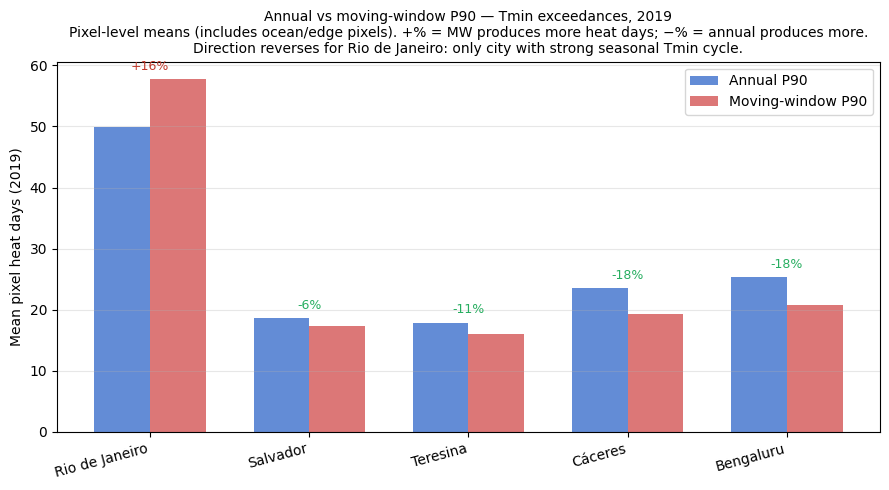

In [40]:
# ---------------------------------------------------------------------------
# Multi-city bar chart: annual vs moving-window mean heat days
# ---------------------------------------------------------------------------

if len(cmp_df) > 0:
    ann_col = 'Annual P90 (px mean)'
    mw_col  = 'MW P90 (px mean)'
    pct_col = 'MW vs Annual (%)'

    cities_plot = cmp_df['City'].tolist()
    x = np.arange(len(cities_plot))
    w = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, cmp_df[ann_col], w, label='Annual P90', color='#4878cf', alpha=0.85)
    ax.bar(x + w/2, cmp_df[mw_col],  w, label='Moving-window P90', color='#d65f5f', alpha=0.85)

    for i, row in cmp_df.iterrows():
        diff  = row[pct_col]
        color = '#c0392b' if diff > 0 else '#27ae60'
        ypos  = max(row[ann_col], row[mw_col]) + 1
        ax.text(i, ypos, f'{diff:+.0f}%', ha='center', va='bottom',
                fontsize=9, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(cities_plot, rotation=15, ha='right')
    ax.set_ylabel('Mean pixel heat days (2019)')
    ax.set_title(
        f'Annual vs moving-window P90 — Tmin exceedances, {TEST_YEAR}\n'
        'Pixel-level means (includes ocean/edge pixels). '
        '+% = MW produces more heat days; −% = annual produces more.\n'
        'Direction reverses for Rio de Janeiro: only city with strong seasonal Tmin cycle.',
        fontsize=10
    )
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


---

## Summary: Four Decisions

**Decision 1 — Use Tmin, not Tmax.**  
In cities with chronically high daytime temperatures, TX90p and TN90p neighbourhood rankings diverge substantially. Overnight minimum temperature reflects the physiological heat stress exposure window — the period during which the body must recover — and is driven by atmospheric moisture and longwave re-emission rather than surface albedo and shade, which dominate Tmax. Where the two metrics agree (moderate ρ), either variable would produce similar prioritisation. Where they diverge, choosing Tmax would systematically misprioritise neighbourhoods. The conservative choice is Tmin.  
**HIT uses GSHTD Tmin as the primary temperature variable.**

**Decision 2 — Use city-wide threshold.**  
The three approaches (city-wide, per-pixel, per-neighbourhood) answer fundamentally different questions. Per-pixel normalisation calibrates each location against its own history, suppressing chronic heat: a permanently hot neighbourhood and a permanently cool neighbourhood can receive identical heat-day counts if both are equally anomalous relative to their own baselines. City-wide calibration applies a common bar, so neighbourhoods that are persistently warmer accumulate more heat days every year — chronic exposure stands out. The low Spearman ρ between city-wide and per-pixel rankings (found across all five cities) is the expected and meaningful result: it confirms that per-pixel normalisation actively suppresses the chronic heat signal that city-wide preserves. For the purpose of identifying neighbourhoods with the highest persistent heat burden, city-wide is the appropriate choice. Within the per-pixel family, method and percentile choice make little difference: the four per-pixel variants (ann_p90, ann_p95, mw_p90, mw_p95) agree at ρ ≥ 0.90 (notebook 29, Key Finding 3).  
**HIT uses a city-wide P90 threshold derived from all raw pixels across the full baseline period.**

**Decision 3 — P90 as primary threshold; P95 is confirmatory.**  
P90 vs P95 neighbourhood rankings agree at ρ ≥ 0.94 across all five cities. Both percentile levels identify the same neighbourhoods as high-priority. P90 is preferred because it provides a larger heat-day count — improving signal-to-noise in cities with low intra-city thermal spread (e.g. Bengaluru) — and aligns with the established ETCCDI TN90p definition.  
**HIT uses P90 as the primary threshold; P95 results are presented for reference.**

**Decision 4 — Annual flat percentile as baseline method; moving-window requires wider testing.**  
The direction of the annual vs moving-window difference reverses between cities: Rio de Janeiro produces more heat days under the moving-window method (+16%), while Salvador, Teresina, Cáceres, and Bengaluru produce more under the annual method (−7% to −18%). This reflects differences in seasonal Tmin cycle amplitude. Within individual cities, annual and moving-window rankings agree at only ρ = 0.4–0.75 — substantially weaker than the pooled cross-city ρ ≥ 0.90 in notebook 29, which was inflated by between-city variance. The annual flat percentile is operationally simpler and performs adequately for the tropical and subtropical cities tested. However, the method is not validated for cities with stronger seasonal cycles (temperate, continental, or monsoon climates).  
**HIT uses the annual flat P90 as the primary baseline method. Moving-window results are retained as a sensitivity check. Wider city testing is required before the annual method can be recommended globally.**


---

## Caveats: Station Validation Limitation

Station-based validation of GSHTD neighbourhood rankings (Decisions 1 and 2) rests on two cities only:

- **Rio de Janeiro** (Alerta Rio network): rank validation comparing GSHTD TN90p neighbourhood rankings against
  station-observed overnight temperatures. This is the primary external validation of whether the 1 km GSHTD
  grid recovers the spatial structure of actual urban heat exposure.
- **Salvador** (ERA5-Land Tmax): a bias check comparing GSHTD Tmax against an independent gridded reanalysis.
  This is a cross-product validation, not a station validation, and covers Tmax only.

**Two cities is insufficient to conclude that GSHTD Tmin neighbourhood rankings are reliable across
all climate contexts, urban morphologies, and dataset vintages.**  
The station validation results from Rio de Janeiro — and any disagreements found — should not be
extrapolated to Teresina, Cáceres, or Bengaluru without equivalent independent data for those cities.

The Alerta Rio validation cells in this notebook will remain empty until the station data is provided.
Results should be reported conditionally on that cell running successfully.

---

## Further Testing

The four decisions above are supported by evidence from at most five cities across three Köppen-Geiger zones
(Aw tropical savanna, Am tropical monsoon, and Cwa humid subtropical). Two areas require dedicated
testing before the methodology can be considered validated for general use:

### 1. Moving-window behaviour across a wider city and climate set

The direction reversal between annual and moving-window methods (Rio +22% vs Salvador −10% vs Bengaluru −18%)
is a function of each city's seasonal Tmin cycle amplitude. The current five-city set is too small and
climatically homogeneous (all tropical or subtropical) to characterise this pattern globally.

Before the annual flat percentile can be recommended as the global default — rather than as a convenient
approximation for the cities tested — the comparison should be extended to cities with contrasting
seasonal structures: arid (e.g. Phoenix, Riyadh), Mediterranean (e.g. Athens, Cape Town),
temperate maritime (e.g. Mumbai monsoon shoulder), and high-altitude tropical (e.g. Addis Ababa, Nairobi).
In cities with strong and asymmetric seasonal cycles, the moving-window method may produce
materially different neighbourhood rankings, not just different counts.

### 2. Tropical nights as a complementary metric to TN90p

Fixed absolute thresholds — TR20 (Tmin > 20 °C) and TR25 (Tmin > 25 °C) — serve a different purpose
from TN90p and should be evaluated as complementary rather than alternative metrics.

TN90p is a relative, city-calibrated metric designed for intra-city spatial prioritisation:
it identifies which neighbourhoods experience more frequent extreme overnight heat *relative to that city's baseline*.
Tropical-night counts are absolute biophysical thresholds: they identify nights on which physiological
heat stress is likely regardless of local climatology.

In cities where baseline overnight temperatures are already near or above 25 °C year-round (e.g. Teresina,
where TR25 nights approach 365 per year), TR25 saturates and loses spatial discrimination — the same
limitation that TN90p was designed to avoid. But in cities with strong seasonal cycles or where
the concern is absolute physiological burden (e.g. identifying urban heat islands that prevent
physiological recovery, rather than identifying relative outliers), TR20/TR25 provide information
that TN90p cannot.

Dedicated testing across a climatically diverse city set — including cities in each of the saturation
and non-saturation regimes for both TR20 and TR25 — is needed to establish whether and when tropical
nights should be reported alongside TN90p in the HIT output.